In [38]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

In [39]:
df = pd.read_csv("data/train_full.csv")

df["image_path"] = df["image_path"].str.replace("\\", "/", regex=False)
df["image_path"] = df["image_path"].str.replace(
    "data/train_data/",
    "data/train_data/train_data/",
    regex=False
)

df.head()

,id,xmin,ymin,xmax,ymax,direction,split,image_path
0,image_0,-228.877144,223.618740,-110.614879,416.358789,1,val,data/train_data/train_data/image_0.png
1,image_2,871.866846,218.142342,945.359631,423.076854,0,train,data/train_data/train_data/image_2.png
2,image_3,-224.589965,220.840143,-146.401974,409.747294,0,val,data/train_data/train_data/image_3.png
3,image_4,898.981190,215.768093,956.279097,429.133944,1,train,data/train_data/train_data/image_4.png
4,image_5,-166.975923,223.755640,-118.486304,369.332377,1,val,data/train_data/train_data/image_5.png


In [40]:
from PIL import Image

def get_image_size(path):
    with Image.open(path) as img:
        return img.size  # (w, h)

sizes = df["image_path"].apply(get_image_size)
df["img_w"] = sizes.apply(lambda x: x[0])
df["img_h"] = sizes.apply(lambda x: x[1])

# original box center and size in pixels
df["cx"] = (df["xmin"] + df["xmax"]) / 2.0
df["cy"] = (df["ymin"] + df["ymax"]) / 2.0
df["bw"] = df["xmax"] - df["xmin"]
df["bh"] = df["ymax"] - df["ymin"]

# normalized center only
df["cx_n"] = df["cx"] / df["img_w"]
df["cy_n"] = df["cy"] / df["img_h"]

# optional clipping to make regression less unstable
df["cx_n"] = df["cx_n"].clip(-0.5, 1.5)
df["cy_n"] = df["cy_n"].clip(-0.5, 1.5)

print(df[["cx_n", "cy_n"]].describe())
print(df["direction"].value_counts())
print(df["split"].value_counts())

              cx_n         cy_n
count  1692.000000  1692.000000
mean      0.477690     0.644443
std       0.735164     0.029736
min      -0.401940     0.595894
25%      -0.243715     0.618708
50%      -0.162558     0.641588
75%       1.210537     0.668755
max       1.351650     0.714528
direction
0    874
1    818
Name: count, dtype: int64
split
train    1353
val       339
Name: count, dtype: int64


In [41]:
def get_side_and_distance(cx_n):
    if cx_n < 0:
        return 0, -cx_n   # left
    elif cx_n > 1:
        return 1, cx_n - 1   # right
    else:
        return None, None

side_dist = df["cx_n"].apply(get_side_and_distance)

df["side"] = side_dist.apply(lambda x: x[0])
df["dist_n"] = side_dist.apply(lambda x: x[1])

# keep only samples that are truly outside
df = df[df["side"].notna()].copy().reset_index(drop=True)

df["side"] = df["side"].astype(int)
df["dist_n"] = df["dist_n"].astype(float)

# optional: clip for stability
df["dist_n"] = df["dist_n"].clip(0.0, 1.5)
df["cy_n"] = df["cy_n"].clip(-0.5, 1.5)

print(df[["cx_n", "cy_n", "side", "dist_n"]].head())
print(df["side"].value_counts())

       cx_n      cy_n  side    dist_n
0 -0.235758  0.666643     0  0.235758
1  1.261963  0.667937     1  0.261963
2 -0.257633  0.656862     0  0.257633
3  1.288375  0.671773     1  0.288375
4 -0.198238  0.617800     0  0.198238
side
0    852
1    840
Name: count, dtype: int64


In [42]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df = df[df["split"] == "val"].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 1353
Val: 339


In [43]:
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(imagenet_mean, imagenet_std),
])

In [44]:
class ShadowCenterDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        img = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            img = self.transform(img)

        center = torch.tensor(
            [row["cx_n"], row["cy_n"]],
            dtype=torch.float32
        )

        direction = torch.tensor(int(row["direction"]), dtype=torch.long)

        meta = {
            "img_w": torch.tensor(row["img_w"], dtype=torch.float32),
            "img_h": torch.tensor(row["img_h"], dtype=torch.float32),
            "id": row["id"]
        }

        return img, center, direction, meta

In [45]:
class ShadowCenterModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Identity()

        # freeze all backbone params first
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.center_head = nn.Sequential(
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )

        self.dir_head = nn.Sequential(
            nn.Linear(in_features, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        features = self.backbone(x)
        center = self.center_head(features)
        direction = self.dir_head(features)
        return center, direction

In [46]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = ShadowCenterModel().to(device)

center_loss_fn = nn.SmoothL1Loss()
dir_loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

Device: cpu


In [47]:
def compute_center_error_pixels(pred_center, true_center, img_w, img_h):
    """
    pred_center: [B, 2] normalized
    true_center: [B, 2] normalized
    img_w, img_h: [B]
    """
    pred_x = pred_center[:, 0] * img_w
    pred_y = pred_center[:, 1] * img_h

    true_x = true_center[:, 0] * img_w
    true_y = true_center[:, 1] * img_h

    err = torch.sqrt((pred_x - true_x) ** 2 + (pred_y - true_y) ** 2)
    return err

In [48]:
def train_one_epoch(model, loader, optimizer, center_loss_fn, dir_loss_fn, device):
    model.train()
    total_loss = 0.0
    total_center_loss = 0.0
    total_dir_loss = 0.0

    for images, true_center, true_dir, _ in loader:
        images = images.to(device)
        true_center = true_center.to(device)
        true_dir = true_dir.to(device)

        optimizer.zero_grad()

        pred_center, pred_dir = model(images)

        center_loss = center_loss_fn(pred_center, true_center)
        dir_loss = dir_loss_fn(pred_dir, true_dir)

        loss = center_loss + dir_loss
        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_center_loss += center_loss.item() * batch_size
        total_dir_loss += dir_loss.item() * batch_size

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "center_loss": total_center_loss / n,
        "dir_loss": total_dir_loss / n
    }

In [49]:
def validate(model, loader, center_loss_fn, dir_loss_fn, device):
    model.eval()

    total_loss = 0.0
    total_center_loss = 0.0
    total_dir_loss = 0.0

    all_dir_correct = []
    all_center_errors = []

    with torch.no_grad():
        for images, true_center, true_dir, meta in loader:
            images = images.to(device)
            true_center = true_center.to(device)
            true_dir = true_dir.to(device)

            pred_center, pred_dir = model(images)

            center_loss = center_loss_fn(pred_center, true_center)
            dir_loss = dir_loss_fn(pred_dir, true_dir)
            loss = center_loss + dir_loss

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_center_loss += center_loss.item() * batch_size
            total_dir_loss += dir_loss.item() * batch_size

            pred_labels = pred_dir.argmax(dim=1)
            correct = (pred_labels == true_dir).float()
            all_dir_correct.extend(correct.cpu().numpy())

            img_w = meta["img_w"].to(device)
            img_h = meta["img_h"].to(device)

            center_errors = compute_center_error_pixels(
                pred_center, true_center, img_w, img_h
            )
            all_center_errors.extend(center_errors.cpu().numpy())

    n = len(loader.dataset)

    return {
        "loss": total_loss / n,
        "center_loss": total_center_loss / n,
        "dir_loss": total_dir_loss / n,
        "dir_acc": float(np.mean(all_dir_correct)),
        "center_error_px": float(np.mean(all_center_errors))
    }

In [50]:
def unfreeze_layer4(model):
    for param in model.backbone.layer4.parameters():
        param.requires_grad = True

In [51]:
import copy,math

In [52]:
train_dataset = ShadowCenterDataset(train_df, transform=train_transform)
val_dataset = ShadowCenterDataset(val_df, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)

In [ ]:
num_epochs = 15
unfreeze_epoch = 6

history = []
best_model_wts = copy.deepcopy(model.state_dict())
best_center_error = float("inf")
best_dir_acc = 0.0
best_epoch = -1

for epoch in range(num_epochs):
    if epoch == unfreeze_epoch:
        print("\nUnfreezing backbone layer4...\n")
        unfreeze_layer4(model)

        optimizer = torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=5e-5,
            weight_decay=1e-4
        )

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode="min",
            factor=0.5,
            patience=2
        )

    train_metrics = train_one_epoch(
        model, train_loader, optimizer, center_loss_fn, dir_loss_fn, device
    )

    val_metrics = validate(
        model, val_loader, center_loss_fn, dir_loss_fn, device
    )

    scheduler.step(val_metrics["loss"])

    row = {
        "epoch": epoch + 1,
        "train_loss": train_metrics["loss"],
        "train_center_loss": train_metrics["center_loss"],
        "train_dir_loss": train_metrics["dir_loss"],
        "val_loss": val_metrics["loss"],
        "val_center_loss": val_metrics["center_loss"],
        "val_dir_loss": val_metrics["dir_loss"],
        "val_dir_acc": val_metrics["dir_acc"],
        "val_center_error_px": val_metrics["center_error_px"],
        "lr": optimizer.param_groups[0]["lr"]
    }
    history.append(row)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_metrics['loss']:.4f} | "
        f"val_loss={val_metrics['loss']:.4f} | "
        f"val_dir_acc={val_metrics['dir_acc']:.4f} | "
        f"val_center_error_px={val_metrics['center_error_px']:.2f} | "
        f"lr={optimizer.param_groups[0]['lr']:.6f}"
    )

    is_better = False
    if val_metrics["center_error_px"] < best_center_error:
        is_better = True
    elif math.isclose(val_metrics["center_error_px"], best_center_error, rel_tol=1e-6):
        if val_metrics["dir_acc"] > best_dir_acc:
            is_better = True

    if is_better:
        best_center_error = val_metrics["center_error_px"]
        best_dir_acc = val_metrics["dir_acc"]
        best_epoch = epoch + 1
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), "best_shadow_center_model.pth")

print(f"\nBest epoch: {best_epoch}")
print(f"Best val center error: {best_center_error:.2f}px")
print(f"Best val dir acc: {best_dir_acc:.4f}")

Epoch 1/15 | train_loss=0.8594 | val_loss=0.8370 | val_dir_acc=0.5044 | val_center_error_px=516.60 | lr=0.000100
Epoch 2/15 | train_loss=0.8310 | val_loss=0.8216 | val_dir_acc=0.5103 | val_center_error_px=480.90 | lr=0.000100
Epoch 3/15 | train_loss=0.8061 | val_loss=0.8079 | val_dir_acc=0.4749 | val_center_error_px=446.76 | lr=0.000100
Epoch 4/15 | train_loss=0.7931 | val_loss=0.7968 | val_dir_acc=0.5133 | val_center_error_px=412.06 | lr=0.000100
Epoch 5/15 | train_loss=0.7863 | val_loss=0.7899 | val_dir_acc=0.4926 | val_center_error_px=384.53 | lr=0.000100
Epoch 6/15 | train_loss=0.7748 | val_loss=0.7861 | val_dir_acc=0.4779 | val_center_error_px=368.52 | lr=0.000100

Unfreezing backbone layer4...

Epoch 7/15 | train_loss=0.7416 | val_loss=0.7392 | val_dir_acc=0.4779 | val_center_error_px=204.35 | lr=0.000050


In [ ]:
results_df = pd.DataFrame(history)
results_df

,epoch,train_loss,train_center_loss,train_dir_loss,val_loss,val_center_loss,val_dir_loss,val_dir_acc,val_center_error_px,lr
0,1,0.867349,0.155968,0.711380,0.820409,0.128407,0.692002,0.533923,511.590424,0.000100
1,2,0.827823,0.130045,0.697778,0.810614,0.118095,0.692519,0.525074,487.879425,0.000100
2,3,0.822400,0.122238,0.700162,0.805328,0.109281,0.696047,0.533923,464.917511,0.000100
3,4,0.798324,0.109052,0.689271,0.793703,0.098897,0.694807,0.542773,432.698334,0.000100
4,5,0.786252,0.100710,0.685543,0.784951,0.089952,0.694999,0.498525,402.518890,0.000100
5,6,0.778761,0.091838,0.686922,0.785500,0.086247,0.699253,0.498525,382.252869,0.000100
6,7,0.740551,0.058070,0.682481,0.732190,0.034330,0.697860,0.510324,204.562332,0.000050
7,8,0.648412,0.031159,0.617253,0.746431,0.025229,0.721202,0.516224,172.984909,0.000050
8,9,0.557630,0.024320,0.533310,0.768633,0.022720,0.745912,0.510324,165.083893,0.000050
9,10,0.412736,0.018310,0.394426,0.845635,0.020661,0.824973,0.501475,156.489975,0.000025


In [ ]:
results_df.sort_values(
    ["val_center_error_px", "val_dir_acc"],
    ascending=[True, False]
).reset_index(drop=True)

,epoch,train_loss,train_center_loss,train_dir_loss,val_loss,val_center_loss,val_dir_loss,val_dir_acc,val_center_error_px,lr
0,14,0.076820,0.016420,0.060400,1.089433,0.018158,1.071275,0.504425,147.120651,0.000013
1,15,0.061357,0.015066,0.046291,1.147679,0.018425,1.129254,0.501475,148.039780,0.000013
2,13,0.115581,0.018317,0.097263,1.074308,0.018735,1.055572,0.486726,149.133545,0.000013
3,12,0.166306,0.019651,0.146655,1.001771,0.019659,0.982112,0.483776,152.058197,0.000025
4,10,0.412736,0.018310,0.394426,0.845635,0.020661,0.824973,0.501475,156.489975,0.000025
5,11,0.242147,0.018022,0.224124,0.906487,0.020933,0.885554,0.474926,159.538376,0.000025
6,9,0.557630,0.024320,0.533310,0.768633,0.022720,0.745912,0.510324,165.083893,0.000050
7,8,0.648412,0.031159,0.617253,0.746431,0.025229,0.721202,0.516224,172.984909,0.000050
8,7,0.740551,0.058070,0.682481,0.732190,0.034330,0.697860,0.510324,204.562332,0.000050
9,6,0.778761,0.091838,0.686922,0.785500,0.086247,0.699253,0.498525,382.252869,0.000100


In [ ]:
model.load_state_dict(torch.load("best_shadow_center_model.pth", map_location=device))
model.eval()

ShadowCenterModel(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True

In [ ]:
import matplotlib.pyplot as plt

inv_normalize = transforms.Normalize(
    mean=[-m / s for m, s in zip(imagenet_mean, imagenet_std)],
    std=[1 / s for s in imagenet_std]
)

def show_predictions(model, dataset, device, num_samples=8):
    model.eval()

    indices = np.random.choice(len(dataset), size=min(num_samples, len(dataset)), replace=False)

    fig, axes = plt.subplots(len(indices), 1, figsize=(8, 4 * len(indices)))
    if len(indices) == 1:
        axes = [axes]

    with torch.no_grad():
        for ax, idx in zip(axes, indices):
            img, true_center, true_dir, meta = dataset[idx]

            input_tensor = img.unsqueeze(0).to(device)
            pred_center, pred_dir = model(input_tensor)

            pred_center = pred_center[0].cpu()
            pred_label = int(pred_dir.argmax(dim=1).item())

            img_w = meta["img_w"].item()
            img_h = meta["img_h"].item()

            true_x = true_center[0].item() * img_w
            true_y = true_center[1].item() * img_h

            pred_x = pred_center[0].item() * img_w
            pred_y = pred_center[1].item() * img_h

            img_disp = inv_normalize(img).clamp(0, 1)
            img_disp = transforms.ToPILImage()(img_disp)

            ax.imshow(img_disp)
            ax.scatter([112], [112], s=20, label="image center")  # just visual reference in resized image

            # points on displayed 224x224 image
            disp_true_x = true_center[0].item() * 224
            disp_true_y = true_center[1].item() * 224
            disp_pred_x = pred_center[0].item() * 224
            disp_pred_y = pred_center[1].item() * 224

            ax.scatter(disp_true_x, disp_true_y, s=80, marker="o", label="true center")
            ax.scatter(disp_pred_x, disp_pred_y, s=80, marker="x", label="pred center")

            ax.set_title(
                f"id={meta['id']} | "
                f"true_dir={int(true_dir.item())} | pred_dir={pred_label}\n"
                f"true_center_px=({true_x:.1f}, {true_y:.1f}) | "
                f"pred_center_px=({pred_x:.1f}, {pred_y:.1f})"
            )
            ax.legend()

    plt.tight_layout()
    plt.show()

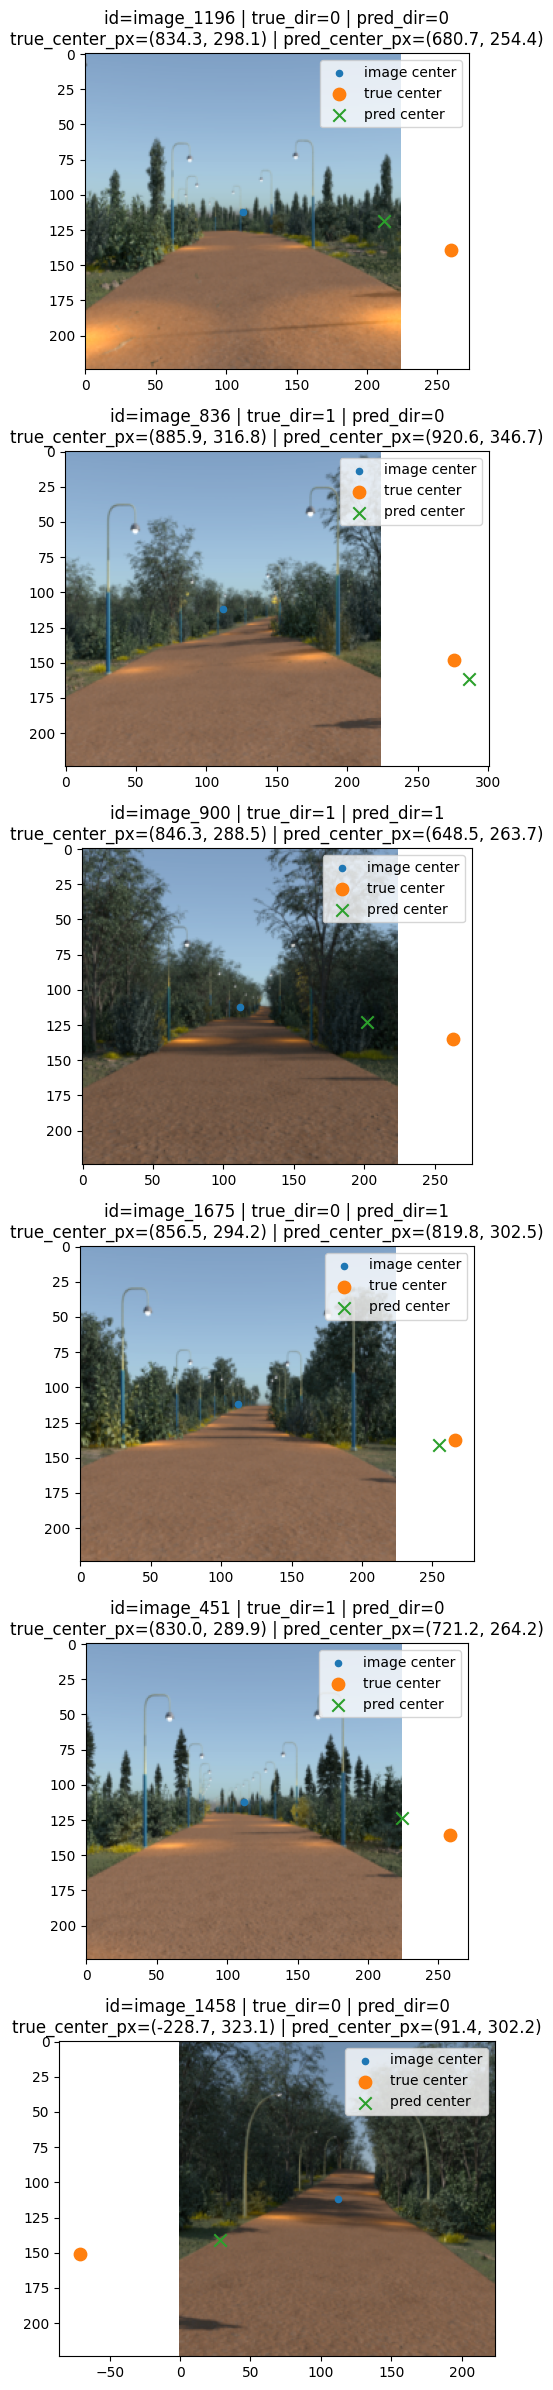

In [ ]:
show_predictions(model, val_dataset, device, num_samples=6)